In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

df = pd.read_csv('data/zomato_clean.csv')
print("Shape:", df.shape)
df.head()

Shape: (51696, 19)


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,cost_for_two,reviews_list,menu_item,listed_type,listed_city,cuisine_count,primary_cuisine
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,3.0,North Indian
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,3.0,Chinese
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,3.0,Cafe
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,2.0,South Indian
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,2.0,North Indian


In [3]:
df_price = df[df['rate'].notna() & 
              df['cost_for_two'].notna() & 
              (df['primary_cuisine'] != 'Unknown')].copy()

df_price['price_bucket'] = pd.cut(
    df_price['cost_for_two'],
    bins=[0, 200, 400, 600, 800, 1000, 6000],
    labels=['₹0-200', '₹200-400', '₹400-600', 
            '₹600-800', '₹800-1000', '₹1000+']
)

print("Price bucket distribution:")
print(df_price['price_bucket'].value_counts().sort_index())

Price bucket distribution:
price_bucket
₹0-200        5169
₹200-400     14307
₹400-600      9253
₹600-800      5395
₹800-1000     2395
₹1000+        5135
Name: count, dtype: int64


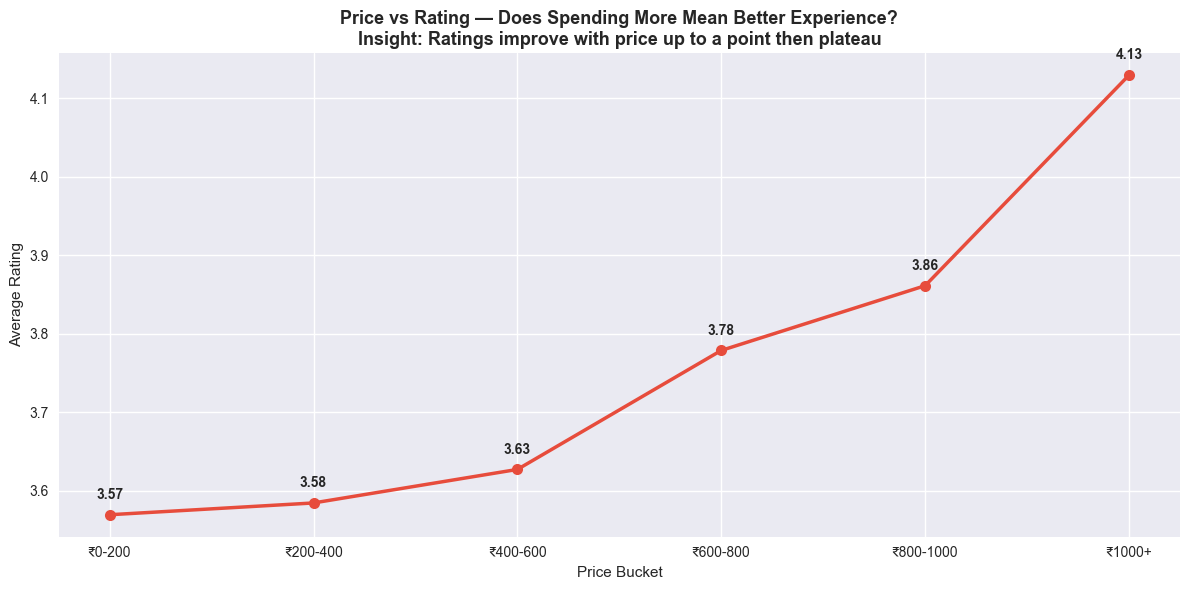

  price_bucket  avg_rating  restaurant_count     avg_cost
0       ₹0-200    3.569607              5169   174.319211
1     ₹200-400    3.584623             14307   335.888027
2     ₹400-600    3.627321              9253   531.859937
3     ₹600-800    3.778906              5395   738.489342
4    ₹800-1000    3.861378              2395   961.565762
5       ₹1000+    4.129601              5135  1590.214216


In [4]:
price_rating = (df_price.groupby('price_bucket', observed=True)
                .agg(avg_rating=('rate', 'mean'),
                     restaurant_count=('name', 'count'),
                     avg_cost=('cost_for_two', 'mean'))
                .reset_index())

plt.figure(figsize=(12, 6))
plt.plot(price_rating['price_bucket'], 
         price_rating['avg_rating'],
         marker='o', linewidth=2.5,
         color='#e74c3c', markersize=8)

for i, row in price_rating.iterrows():
    plt.text(i, row['avg_rating'] + 0.02,
             f"{row['avg_rating']:.2f}",
             ha='center', fontweight='bold')

plt.xlabel('Price Bucket')
plt.ylabel('Average Rating')
plt.title('Price vs Rating — Does Spending More Mean Better Experience?\n'
          'Insight: Ratings improve with price up to a point then plateau',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(price_rating)

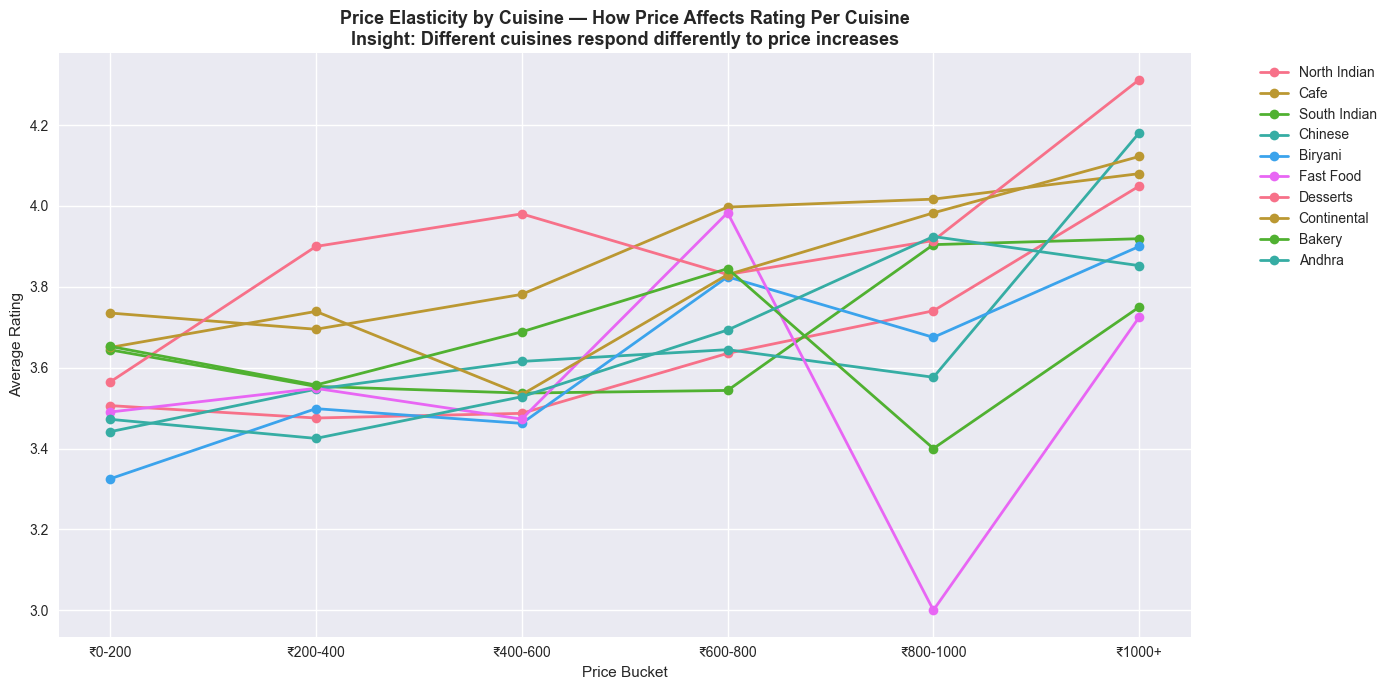

In [5]:
top_cuisines = (df_price['primary_cuisine']
                .value_counts()
                .head(10)
                .index.tolist())

cuisine_price = (df_price[df_price['primary_cuisine'].isin(top_cuisines)]
                 .groupby(['primary_cuisine', 'price_bucket'], observed=True)
                 .agg(avg_rating=('rate', 'mean'),
                      count=('name', 'count'))
                 .reset_index())

plt.figure(figsize=(14, 7))
for cuisine in top_cuisines:
    data = cuisine_price[cuisine_price['primary_cuisine'] == cuisine]
    if len(data) >= 3:
        plt.plot(data['price_bucket'],
                 data['avg_rating'],
                 marker='o', label=cuisine, linewidth=2)

plt.xlabel('Price Bucket')
plt.ylabel('Average Rating')
plt.title('Price Elasticity by Cuisine — How Price Affects Rating Per Cuisine\n'
          'Insight: Different cuisines respond differently to price increases',
          fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [6]:
from scipy import stats

elasticity_results = []

for cuisine in top_cuisines:
    data = df_price[df_price['primary_cuisine'] == cuisine].copy()
    if len(data) >= 30:
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            data['cost_for_two'], data['rate']
        )
        elasticity_results.append({
            'cuisine': cuisine,
            'elasticity': round(slope * 100, 4),
            'r_squared': round(r_value**2, 3),
            'p_value': round(p_value, 4),
            'sample_size': len(data)
        })

elasticity_df = pd.DataFrame(elasticity_results).sort_values(
    'elasticity', ascending=False
)

print(elasticity_df)

        cuisine  elasticity  r_squared  p_value  sample_size
4       Biryani      0.0637      0.111   0.0000         2227
9        Andhra      0.0608      0.098   0.0000          980
1          Cafe      0.0476      0.077   0.0000         3987
3       Chinese      0.0405      0.162   0.0000         2539
6      Desserts      0.0384      0.038   0.0000         1686
0  North Indian      0.0369      0.144   0.0000         9840
7   Continental      0.0315      0.177   0.0000         1671
8        Bakery      0.0160      0.004   0.0166         1452
5     Fast Food      0.0126      0.003   0.0182         1896
2  South Indian      0.0114      0.005   0.0000         3546


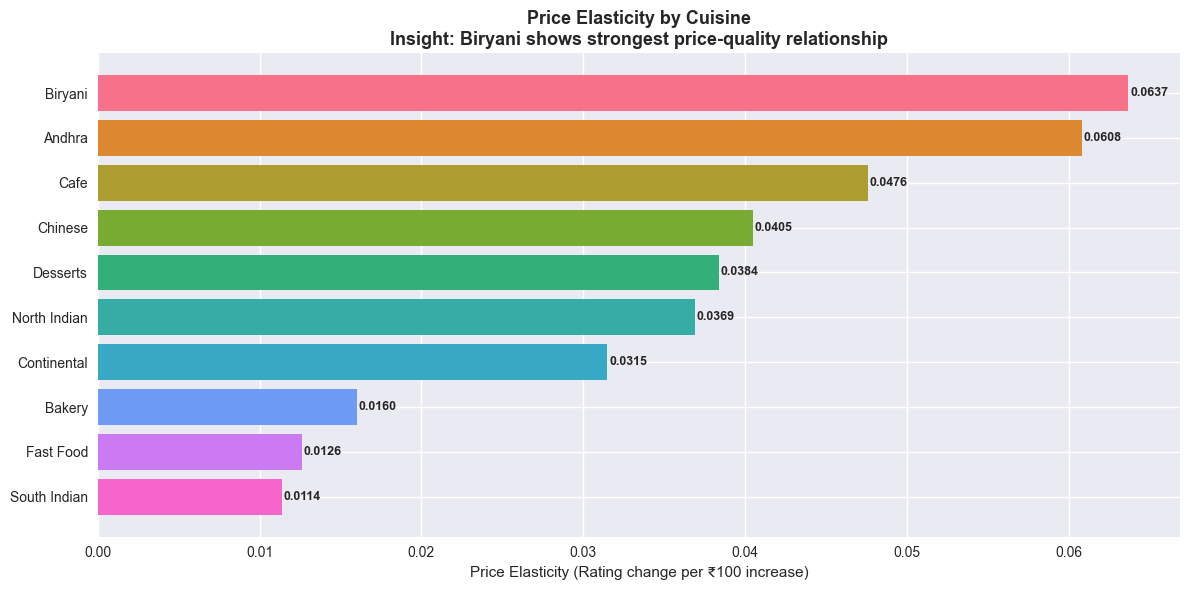

In [7]:
plt.figure(figsize=(12, 6))
bars = plt.barh(elasticity_df['cuisine'],
                elasticity_df['elasticity'],
                color=sns.color_palette("husl", len(elasticity_df)))

for bar, val in zip(bars, elasticity_df['elasticity']):
    plt.text(bar.get_width() + 0.0001,
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}',
             va='center', fontweight='bold', fontsize=9)

plt.xlabel('Price Elasticity (Rating change per ₹100 increase)')
plt.title('Price Elasticity by Cuisine\n'
          'Insight: Biryani shows strongest price-quality relationship',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
recommendations = {
    'Finding 1': 'Biryani has highest price elasticity — Zomato should '
                 'promote premium Biryani restaurants (₹600+) as quality '
                 'scales strongly with price in this category',
    
    'Finding 2': 'The ₹200-400 bucket has 14,307 restaurants — most '
                 'competitive segment. New restaurants should either go '
                 'budget (₹0-200) or premium (₹800+) to avoid the '
                 'crowded middle',
    
    'Finding 3': 'Ratings jump significantly at ₹1000+ (4.13 avg) — '
                 'Zomato should create a dedicated premium dining section '
                 'for restaurants above ₹1000 for two',
    
    'Finding 4': 'Modern Indian cuisine has highest success rate but low '
                 'volume — significant white space opportunity for new '
                 'premium Modern Indian restaurants in Bangalore'
}

print("PRICE ELASTICITY — BUSINESS RECOMMENDATIONS")
for key, value in recommendations.items():
    print(f"\n{key}:")
    print(f"  {value}")


PRICE ELASTICITY — BUSINESS RECOMMENDATIONS

Finding 1:
  Biryani has highest price elasticity — Zomato should promote premium Biryani restaurants (₹600+) as quality scales strongly with price in this category

Finding 2:
  The ₹200-400 bucket has 14,307 restaurants — most competitive segment. New restaurants should either go budget (₹0-200) or premium (₹800+) to avoid the crowded middle

Finding 3:
  Ratings jump significantly at ₹1000+ (4.13 avg) — Zomato should create a dedicated premium dining section for restaurants above ₹1000 for two

Finding 4:
  Modern Indian cuisine has highest success rate but low volume — significant white space opportunity for new premium Modern Indian restaurants in Bangalore
